## 把healpix天图转成wcs天图

In [122]:
#导入包. 设置频率轴. 设置画图格式.
import healpy as hp
import numpy as np
from   astropy.io import fits
from   scipy.interpolate import interp1d
import matplotlib as mpl  # matplotlib基础
import matplotlib.pyplot as plt
from   astropy.wcs import WCS

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,
    "xtick.top": False,
    "ytick.left": True,
    "ytick.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
})

# =========================
# 1. 频率函数
# =========================
def cal_freq(ch_list):
    freq_list = []
    v_min = 856.0
    dv = 0.208984375
    for ch in ch_list:
        freq_MHz = ch * dv + v_min
        freq = freq_MHz * 1e6
        freq_list.append(freq)
    return np.array(freq_list)

# =========================
# 2. 目标频率轴（MHz）
# =========================
n_channels = 4096
freq_axis = cal_freq(np.arange(n_channels)) / 1e6
freq_mask = (freq_axis >= 971.0) & (freq_axis <= 1023.8)
FREQ_TARGET = freq_axis[freq_mask]   # MHz
N_FREQ_TARGET = len(FREQ_TARGET)

In [123]:
# 参数
N_phi          = 72
beam_rotation  = 60
theta_range    = 90         # 波束范围
sky_components = "f1s1d1c1" # 天空成分标签

In [124]:
# 文件路径模板
spin1 = 0 # 波束旋转角,永远是0不要改
spin2 = spin1+beam_rotation # 波束旋转角
healpix_template = (
    "healpix_map/dirk_healpix_N"+str(N_phi)+"_sp{spin}_theta{theta}_{components}.fits"
)
wcs_template = (
    "wcs_map/dirk_wcs_N"+str(N_phi)+"_sp{beam_rotation}_theta{theta}_{components}.fits"
)

# Healpix 输入文件
filename1 = healpix_template.format(
    spin=spin1,
    theta=theta_range,
    components=sky_components,
)
filename2 = healpix_template.format(
    spin=spin2,
    theta=theta_range,
    components=sky_components,
)
# WCS 输出文件
save_file_name = wcs_template.format(
    beam_rotation=beam_rotation,
    theta=theta_range,
    components=sky_components,
)
print(save_file_name)
# 读取第一组healpix天图
Healpix_maps1 = hp.read_map(
    filename1,
    field=None,
).astype(np.float64)
Healpix_maps1[Healpix_maps1 == hp.UNSEEN] = np.nan # 将 UNSEEN 替换为 NaN
# 读取第二组healpix天图
Healpix_maps2 = hp.read_map(
    filename2,
    field=None,
).astype(np.float64)
Healpix_maps2[Healpix_maps2 == hp.UNSEEN] = np.nan # 将 UNSEEN 替换为 NaN

# 按像素取平均
# np.nanmean 会自动忽略 NaN
Healpix_maps = np.nanmean(
    np.stack(
        [
            Healpix_maps1,
            Healpix_maps2,
        ],
        axis=0,
    ),
    axis=0,
)

wcs_map/dirk_wcs_N72_sp60_theta90_f1s1d1c1.fits


/tmp/ipykernel_2695704/2158461274.py:44: RuntimeWarning: Mean of empty slice
  Healpix_maps = np.nanmean(


In [125]:
# 读取频率（从列名解析）
with fits.open(filename2) as hdul:
    FREQ_HP = np.array([
        float(col.name[1:-3])  # 去掉 'F' 和 'MHz'
        for col in hdul[1].columns
    ])
N_FREQ_HP, NPIX = Healpix_maps.shape

# =========================
# 5. 读取目标 cube
# =========================
with fits.open("data/T_cube_trim.fits") as hdul:
    T_cube_trim = hdul[0].data
    HEADER = hdul[0].header

cube_shape = T_cube_trim.shape
print("T_cube_trim shape:", cube_shape)

NX, NY, _ = cube_shape
# =========================
# 6. 构建 WCS
# =========================
WCS_2D = WCS(HEADER, naxis=2)

# =========================
# 7. 像素网格
# =========================
X, Y = np.indices((NX, NY))

# =========================
# 8. 像素 → 天球 → HEALPix
# =========================
RA, DEC = WCS_2D.wcs_pix2world(X, Y, 0)
RA = np.mod(RA, 360.0)

THETA = np.radians(90.0 - DEC)
PHI   = np.radians(RA)

NSIDE = hp.get_nside(Healpix_maps[0])
PIX = hp.ang2pix(NSIDE, THETA, PHI)

# =========================
# 9. HEALPix → WCS（原频率）
# =========================
WCS_from_HP = np.zeros((NX, NY, N_FREQ_HP), dtype=np.float64)

for idx in range(N_FREQ_HP):
    layer = Healpix_maps[idx]
    projected = layer[PIX]
    projected = np.nan_to_num(projected, nan=0.0)
    WCS_from_HP[:, :, idx] = projected

# =========================
# 10. 频率插值
# =========================
# reshape 为 (freq, pixel)
DATA_2D = WCS_from_HP.reshape(-1, N_FREQ_HP).T

interp_func = interp1d(
    FREQ_HP,
    DATA_2D,
    axis=0,
    bounds_error=False,
    fill_value=0.0
)

NEW_DATA_2D = interp_func(FREQ_TARGET)
Wcs_maps = NEW_DATA_2D.T.reshape(NX, NY, N_FREQ_TARGET)/1000 #换回K，和真实数据一致, 不加cmb平均温度. 虽然不确定是不是应该在这里加

# =========================
# 10.5 填充回完整 4096 频率轴
# =========================

real_fits_file = "/idia/projects/meerklass/MEERKLASS-2/Lband_2021/level6/Nscan961_Tsky_cube_p0.3d_sigma4.0_iter2.fits"

with fits.open(real_fits_file) as hdul:
    real_data_cube = hdul[0].data

FULL_MAP = real_data_cube.copy()
FULL_MAP = np.ones_like(real_data_cube)
FULL_MAP[:, :, freq_mask] = Wcs_maps                         #将已有频率段填入对应位置

# =========================
# 11. 写 FITS
# =========================
HEADER_WCS = WCS_2D.to_header()

HEADER_WCS["NAXIS"]  = 3
HEADER_WCS["NAXIS1"] = NX
HEADER_WCS["NAXIS2"] = NY
HEADER_WCS["NAXIS3"] = n_channels

fits.PrimaryHDU(data=FULL_MAP, header=HEADER_WCS).writeto(
    save_file_name,
    overwrite=True
)

T_cube_trim shape: (133, 73, 252)


## 检查输出结果

In [126]:
np.shape(FULL_MAP)

(133, 73, 4096)

In [127]:
with fits.open(save_file_name) as hdul:
    hdul.info()
    data = hdul[0].data
    header = hdul[0].header
    wcs_2d = WCS(header, naxis=2)
print("shape:", data.shape)

Filename: wcs_map/dirk_wcs_N72_sp60_theta90_f1s1d1c1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      21   (4096, 73, 133)   float64   
shape: (133, 73, 4096)


In [128]:
print(list(header.keys()))

['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2', 'NAXIS3', 'WCSAXES', 'CRPIX1', 'CRPIX2', 'CDELT1', 'CDELT2', 'CUNIT1', 'CUNIT2', 'CTYPE1', 'CTYPE2', 'CRVAL1', 'CRVAL2', 'LONPOLE', 'LATPOLE', 'MJDREF', 'RADESYS']


In [129]:
freq_MHz = FREQ_TARGET
# 找最接近 1000 MHz
target = 990
i_frequency = np.argmin(np.abs(freq_axis - target))

print(f"channel = {i_frequency}, freq = {freq_axis[i_frequency]:.3f} MHz")

channel = 641, freq = 989.959 MHz


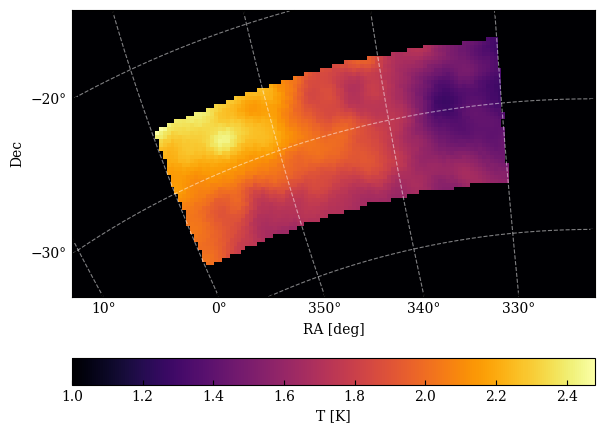

In [130]:
# 创建带 WCS 投影的坐标轴
fig, ax = plt.subplots(subplot_kw={"projection": wcs_2d})
plt.tight_layout()
# 显示二维数据切片
im = ax.imshow(data[:, :, i_frequency].T, origin="lower",cmap = "inferno", vmin = 1)

# RA 使用度数格式
ax.coords[0].set_format_unit("deg")
ax.invert_xaxis()
# 坐标轴标签
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec")
ax.coords.grid(True, color="white", ls="--", alpha=0.5)
# 在下方添加水平 colorbar
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.15)

# 设置标签
cbar.set_label("T [K]")
plt.show()

(970.0, 1024.0)

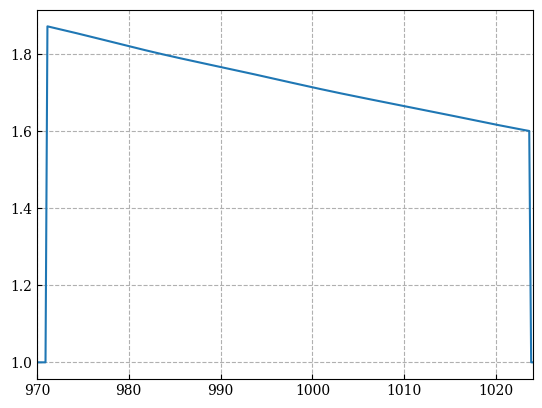

In [131]:
plt.plot(freq_axis, data[77,25,:])
plt.xlim(970, 1024)

In [132]:
FULL_MAP.shape

(133, 73, 4096)

## 